# Declearn Profiling Report

## Setup

In [18]:
import pstats
import os
import json
import subprocess
import matplotlib.pyplot as plt

# automatically find the most recent results folder
results_base = "results"
all_runs = sorted(os.listdir(results_base))
results_dir = os.path.join(results_base, all_runs[-1])

print(f"Loading results from: {results_dir}")
print(f"Contents: {os.listdir(results_dir)}")

Loading results from: results/config_2026-04-15_15-29
Contents: ['memray.bin', 'memray_top_functions.png', 'comparison_cprofile_vs_yappi.png', 'cprofile_vs_yappi.png', 'cprofile.prof', 'yappi_vs_pyspy.png', 'yappi.prof', 'yappi_top_functions.png', 'pyspy_speedscope.json']


## Helpers

In [19]:
def is_declearn(filepath):
    """Check if a function belongs to a declearn subpackage."""
    if "declearn/declearn/" not in filepath:
        return False
    parts = filepath.split("declearn/declearn/")[1].split("/")
    if len(parts) <= 1:
        return False
    return parts[0] in [
        "model", "optimizer", "dataset", "training", "metrics",
        "main", "utils", "communication", "messaging"
    ]


def extract_functions(stats):
    """Extract function data from a pstats.Stats object."""
    functions = []
    for (file, line, name), (cc, nc, tt, ct, callers) in stats.stats.items():
        if tt == 0:
            continue
        functions.append({
            "name": name,
            "file": file,
            "tottime": tt,
            "cumtime": ct,
            "ncalls": nc,
            "self_ratio": tt / ct if ct > 0 else 0,
            "percall": tt / nc if nc > 0 else 0,
            "is_declearn": is_declearn(file),
        })
    return functions


def get_top_functions(func_list, n=15):
    """Get top N functions sorted by cumtime."""
    sorted_funcs = sorted(func_list, key=lambda x: x["cumtime"], reverse=True)
    return sorted_funcs[:n]

## Load profiling data

In [20]:
# Load cProfile
cprofile_path = os.path.join(results_dir, "cprofile.prof")
cp_stats = pstats.Stats(cprofile_path)
cp_functions = extract_functions(cp_stats)
cp_declearn = [f for f in cp_functions if f["is_declearn"]]

# Load Yappi
yappi_path = os.path.join(results_dir, "yappi.prof")
yp_stats = pstats.Stats(yappi_path)
yp_functions = extract_functions(yp_stats)
yp_declearn = [f for f in yp_functions if f["is_declearn"]]

print(f"cProfile: {cp_stats.total_tt:.2f}s wall-clock | {len(cp_functions)} total functions | {len(cp_declearn)} declearn")
print(f"Yappi:    {yp_stats.total_tt:.2f}s CPU time   | {len(yp_functions)} total functions | {len(yp_declearn)} declearn")

cProfile: 54.07s wall-clock | 20730 total functions | 587 declearn
Yappi:    30.79s CPU time   | 3015 total functions | 316 declearn


## 1. cProfile vs Yappi



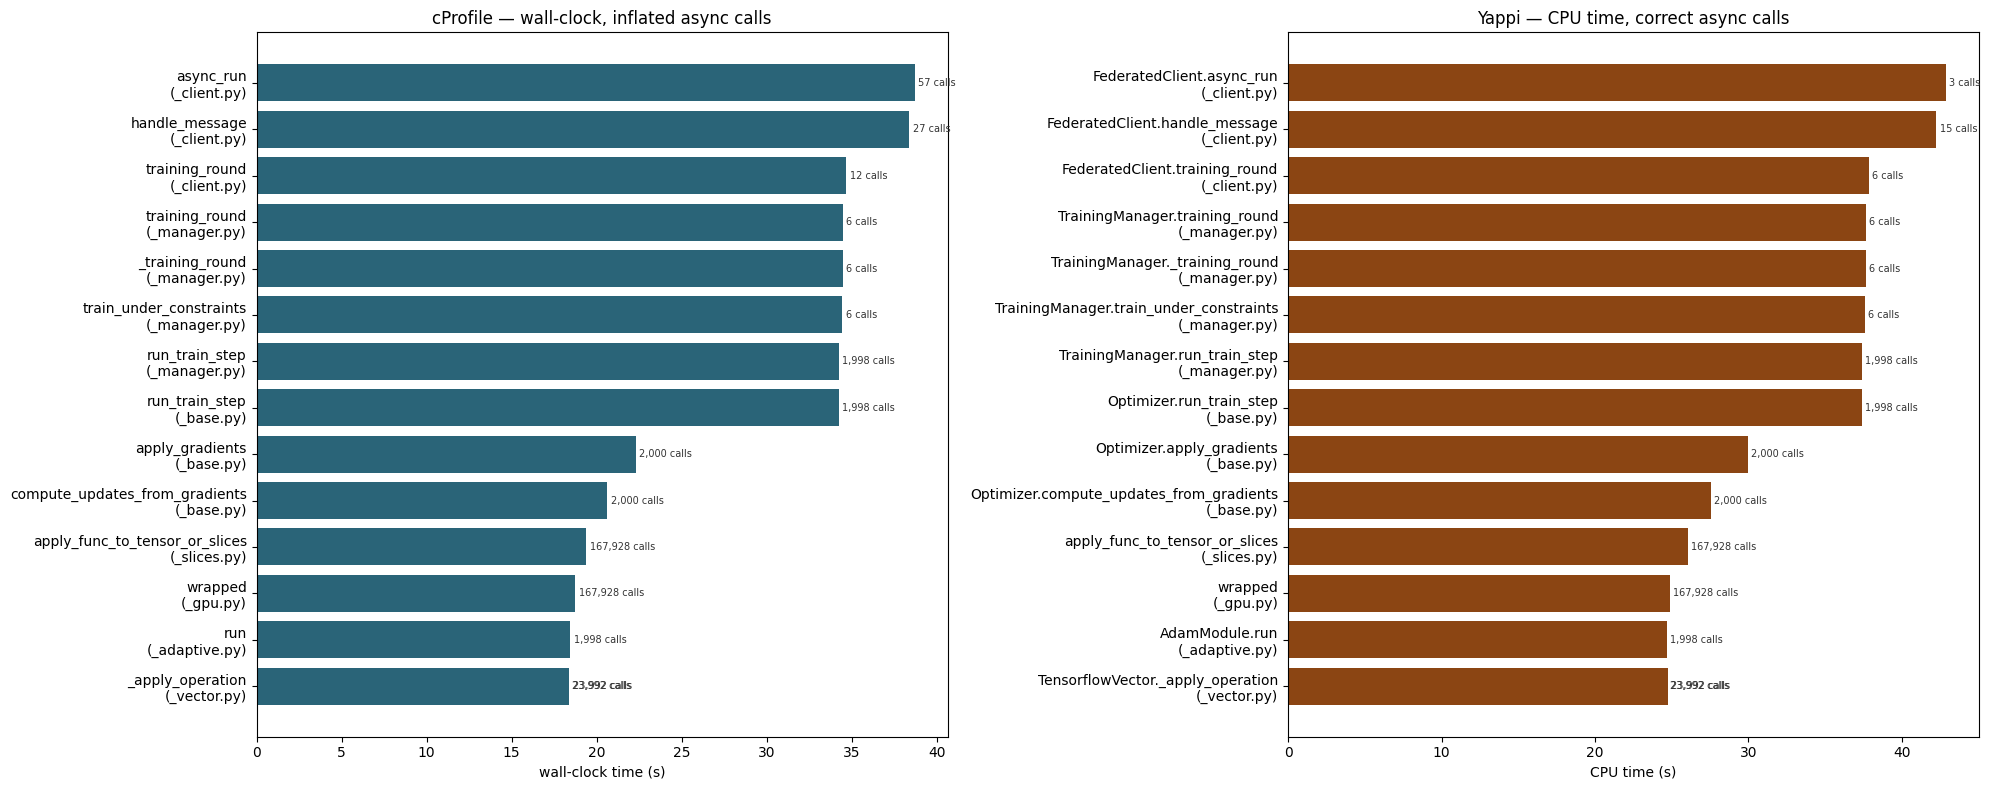

In [21]:
cp_top = get_top_functions(cp_declearn)
yp_top = get_top_functions(yp_declearn)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# cProfile chart
cp_plot = list(reversed(cp_top))
labels_cp = [f"{f['name']}\n({os.path.basename(f['file'])})" for f in cp_plot]
bars1 = ax1.barh(labels_cp, [f["cumtime"] for f in cp_plot], color="#2a6478")
for i, (bar, f) in enumerate(zip(bars1, cp_plot)):
    w = bar.get_width()
    ax1.text(w + 0.2, bar.get_y() + bar.get_height()/2,
             f"{f['ncalls']:,} calls",
             va='center', fontsize=7, color='#333')
ax1.set_xlabel("wall-clock time (s)")
ax1.set_title("cProfile \u2014 wall-clock, inflated async calls")

# Yappi chart
yp_plot = list(reversed(yp_top))
labels_yp = [f"{f['name']}\n({os.path.basename(f['file'])})" for f in yp_plot]
bars2 = ax2.barh(labels_yp, [f["cumtime"] for f in yp_plot], color="#8b4513")
for i, (bar, f) in enumerate(zip(bars2, yp_plot)):
    w = bar.get_width()
    ax2.text(w + 0.2, bar.get_y() + bar.get_height()/2,
             f"{f['ncalls']:,} calls",
             va='center', fontsize=7, color='#333')
ax2.set_xlabel("CPU time (s)")
ax2.set_title("Yappi \u2014 CPU time, correct async calls")

plt.tight_layout()
plt.savefig(os.path.join(results_dir, "cprofile_vs_yappi.png"), dpi=150)
plt.show()

## 2. Yappi vs py-spy — deterministic vs statistical profiling

Yappi traces every function call (deterministic). py-spy samples the call stack 100x/second (statistical).  
If both tools agree on the ranking, the results are trustworthy.

In [22]:
# Load py-spy speedscope data
speedscope_path = os.path.join(results_dir, "pyspy_speedscope.json")
with open(speedscope_path, "r") as f:
    speedscope = json.load(f)

profiles = speedscope.get("profiles", [])
shared_frames = speedscope.get("shared", {}).get("frames", [])

# aggregate time per function
profile = profiles[0]
samples = profile["samples"]
weights = profile["weights"]

frame_time = {}
for stack, weight in zip(samples, weights):
    for frame_idx in stack:
        frame = shared_frames[frame_idx]
        name = frame["name"]
        filepath = frame.get("file", "")
        key = (name, filepath)
        frame_time[key] = frame_time.get(key, 0) + weight

# filter for declearn functions
pyspy_declearn = [
    {"name": name, "file": filepath, "time": t}
    for (name, filepath), t in frame_time.items()
    if is_declearn(filepath)
]
pyspy_declearn.sort(key=lambda x: x["time"], reverse=True)

print(f"Declearn functions captured by py-spy: {len(pyspy_declearn)}")
print()
for f in pyspy_declearn[:15]:
    short_file = os.path.basename(f["file"])
    print(f"  {f['time']:6.2f}s  {f['name']} ({short_file})")

Declearn functions captured by py-spy: 145

   21.84s  async_run (_client.py)
   21.68s  handle_message (_client.py)
   19.17s  training_round (_client.py)
   18.88s  training_round (_manager.py)
   18.88s  _training_round (_manager.py)
   18.85s  train_under_constraints (_manager.py)
   18.65s  run_train_step (_manager.py)
   18.65s  run_train_step (_base.py)
   16.35s  apply_gradients (_base.py)
   15.40s  compute_updates_from_gradients (_base.py)
   15.09s  <dictcomp> (_vector.py)
   14.89s  apply_func_to_tensor_or_slices (_slices.py)
   14.66s  wrapped (_gpu.py)
   14.03s  run (_adaptive.py)
   13.67s  _apply_operation (_vector.py)


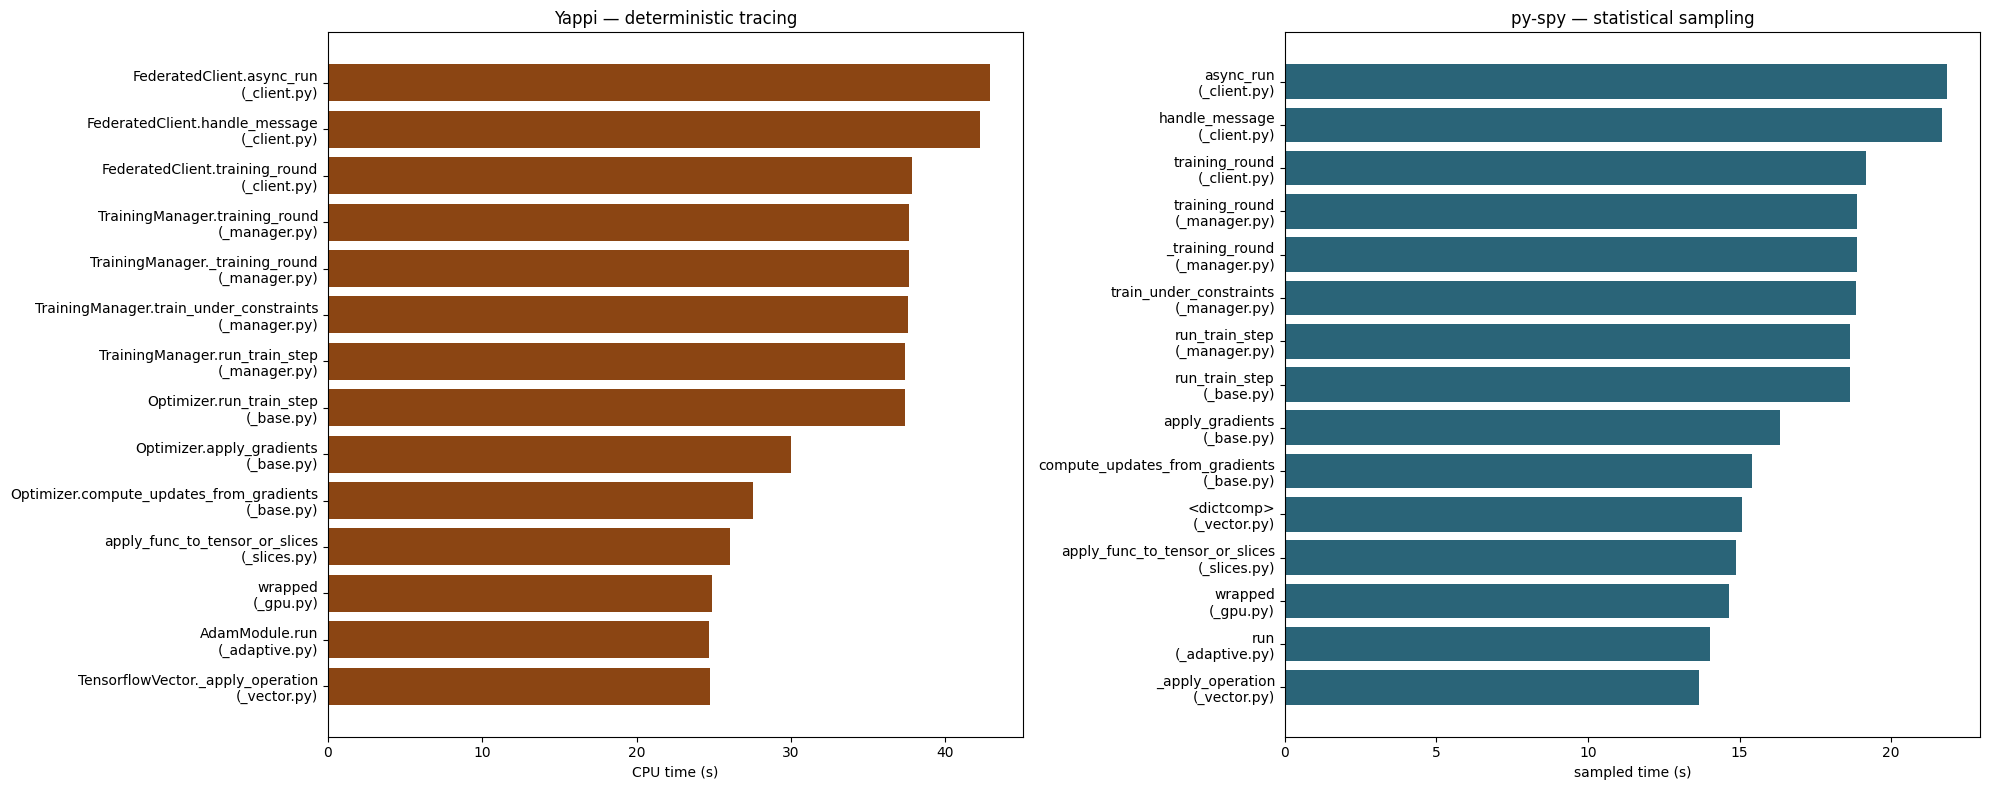

In [23]:
pyspy_top = pyspy_declearn[:15]
pyspy_top.reverse()

yp_top_compare = get_top_functions(yp_declearn)
yp_top_compare.reverse()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Yappi chart
ax1.barh(
    [f"{f['name']}\n({os.path.basename(f['file'])})" for f in yp_top_compare],
    [f["cumtime"] for f in yp_top_compare],
    color="#8b4513"
)
ax1.set_xlabel("CPU time (s)")
ax1.set_title("Yappi \u2014 deterministic tracing")

# py-spy chart
ax2.barh(
    [f"{f['name']}\n({os.path.basename(f['file'])})" for f in pyspy_top],
    [f["time"] for f in pyspy_top],
    color="#2a6478"
)
ax2.set_xlabel("sampled time (s)")
ax2.set_title("py-spy \u2014 statistical sampling")

plt.tight_layout()
plt.savefig(os.path.join(results_dir, "yappi_vs_pyspy.png"), dpi=150)
plt.show()

## 3. memray — Memory Profiling

memray tracks every memory allocation at the C level.  
It shows peak memory usage, total allocations, and which functions allocate the most.

Peak memory: 520.0 MB
Total allocations: 34,454,546



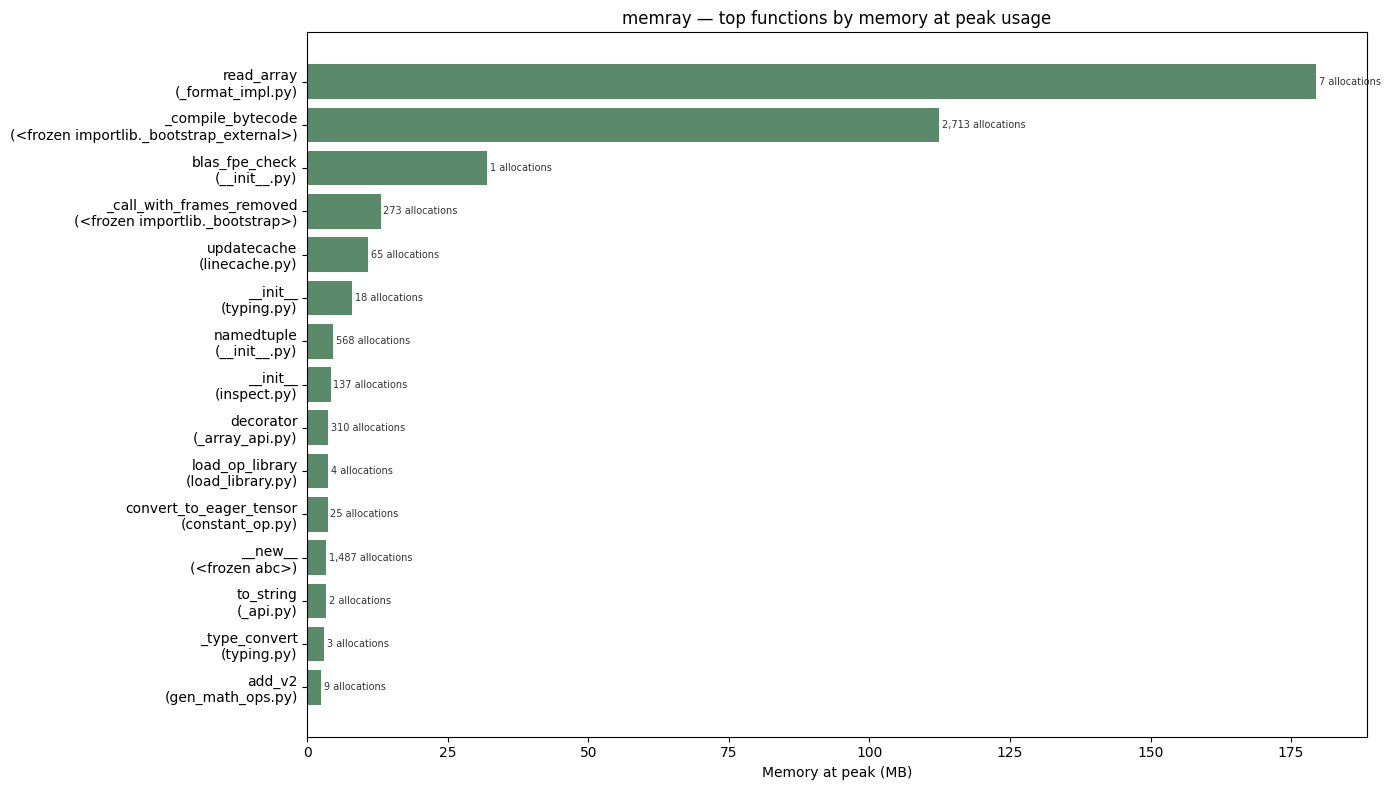

In [24]:
# Parse memray data using the Python API
from memray import FileReader
from collections import defaultdict

bin_path = os.path.join(results_dir, "memray.bin")
reader = FileReader(bin_path)

# high-level stats
metadata = reader.metadata
print(f"Peak memory: {metadata.peak_memory / 1024 / 1024:.1f} MB")
print(f"Total allocations: {metadata.total_allocations:,}")
print()

# aggregate memory by function at peak (using the top frame of each record)
records = list(reader.get_high_watermark_allocation_records())
func_memory = defaultdict(lambda: {"size": 0, "count": 0})

for r in records:
    trace = r.stack_trace()
    if not trace:
        continue
    name, filepath, line = trace[0]
    key = (name, filepath)
    func_memory[key]["size"] += r.size
    func_memory[key]["count"] += 1

mem_ranked = sorted(func_memory.items(), key=lambda x: x[1]["size"], reverse=True)

# plot top 15 memory consumers
top_mem = mem_ranked[:15]
top_mem.reverse()

fig, ax = plt.subplots(figsize=(14, 8))
labels = [f"{name}\n({os.path.basename(filepath)})" for (name, filepath), _ in top_mem]
sizes_mb = [v["size"] / 1024 / 1024 for _, v in top_mem]
counts = [v["count"] for _, v in top_mem]

bars = ax.barh(labels, sizes_mb, color="#5a8a6a")

for i, (bar, count) in enumerate(zip(bars, counts)):
    w = bar.get_width()
    ax.text(w + 0.5, bar.get_y() + bar.get_height()/2,
            f"{count:,} allocations",
            va='center', fontsize=7, color='#333')

ax.set_xlabel("Memory at peak (MB)")
ax.set_title("memray \u2014 top functions by memory at peak usage")
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "memray_top_functions.png"), dpi=150)
plt.show()

 memory_profiler: python library but inactive since 2 years and decoration based 

## 4. CONSLUSION 
# CI 
 Py-spy et Memray   
 Quickrun avec des different configs comme un benchmark  (pour faire apparaitre tous les parametres) 
 Lancer plusieurs fois et faire la mediane pour eviter le bruit   
 Comparaison avec l'ancien version   
 parser les resultats et Generer un rapport qui montre toujours les top consomateurs de temps/memoire et les diffs entre les versions  

# Investigation
 preparer des benchmark modulaire pour l'isolation   
 preparer des scripts et les documenter avec des outils plus specifique par module 

